In [12]:
import numpy as np
import matplotlib.pyplot as plt

CONSTANTS

In [13]:
T = 10 ** (-6)
f_0 = 10 ** 5
w_0 = 2 * np.pi * f_0
phi = np.pi / 8
A = 1
N = 513
n_0 = int( - (N - 1) / 2)

P = (N * (N - 1)) / 2
Q = (N * (N - 1) * (2*N - 1)) / 6

SNR_db_list = np.array([-10, 0, 10, 20, 30, 40, 50, 60])
SNR_list = 10 ** (SNR_db_list / 20)
variance_list = A ** 2 / 2 * SNR_list
standard_deviation_list = np.sqrt(variance_list)

k = np.array([10, 12, 14, 16, 18, 20])
m_values = 2 ** k

Generating instances

In [14]:
def X(t, standard_deviation):

    if type(t) != np.ndarray:
        t = np.array(t)

    real_noise = np.random.normal(0, standard_deviation, t.shape)
    imaginary_noise = np.random.normal(0, standard_deviation, t.shape)

    complex_noise = real_noise + 1j * imaginary_noise

    return A * np.exp(1j * (w_0 * t + phi)) + complex_noise

Get m from the fft

In [ ]:
def Max_FFT(x, M):
    fft_x = np.fft.fft(x, M)
    absolute_fft_x = np.abs(fft_x)
    k  = np.argmax(absolute_fft_x)
    max_omega = absolute_fft_x[k]
    return max_omega

Estimate radial frequency

In [16]:
def W_estimate(m, M):
    return (2 * np.pi * m) / (M * T)

Estimate phase

In [17]:
def F(w_estimate, standard_deviation):

    sum = 0
    for n in range(n_0, n_0 + N, 1):
        sum += X(n*T, standard_deviation) * np.exp(- 1j * w_estimate * n * T)

    F = sum / N

    return F

def Phi_estimate(w_estimate, standard_deviation):

    phi_estimate = np.angle(np.exp(- 1j * w_estimate * n_0 * T) * F(w_estimate, standard_deviation))
    
    return phi_estimate

Compute CRLB

In [18]:
def W_CRLB(standard_deviation):

    CRLB = (12 * standard_deviation**2) / (A**2 * T**2 * N * (N**2 - 1))

    return CRLB

def Phi_CRLB(standard_deviation):

    CRLB = (12 * standard_deviation**2 * (n_0**2 * N + 2 * n_0 * P + Q)) / (A**2 * N * (N**2 - 1))

    return CRLB

Simulate

In [19]:
def Sim_estimation(m, standard_deviation):

    t = np.arange(n_0, n_0 + N, 1) * T
    x_values = X(t, standard_deviation)
    
    max_fft = Max_FFT(x_values, m)
    ...

    max_fft = Max_FFT(x_values, m)

    w_est = W_estimate(max_fft, m)
    phi_est = Phi_estimate(w_est, standard_deviation)

    return w_est, phi_est

Plotting

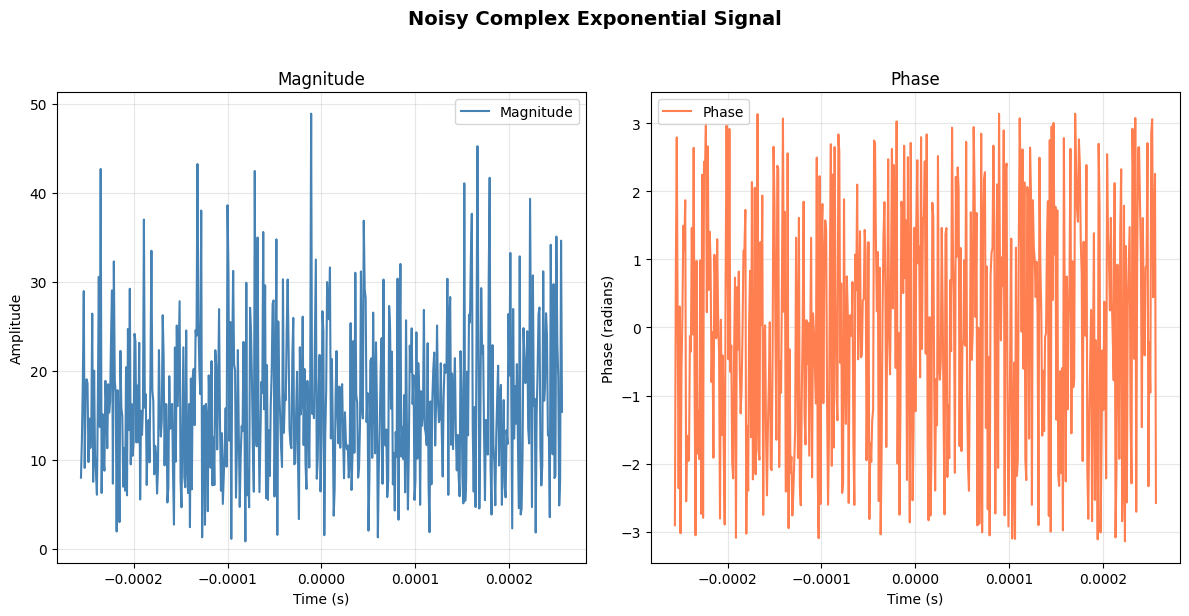

In [20]:
t = np.arange(n_0, n_0 + N, 1) * T
x_values = X(t,standard_deviation_list[6]) # Using the highest SNR for visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Noisy Complex Exponential Signal', fontsize=14, fontweight='bold', y=1.02)

# Magnitude plot
ax1.plot(t, np.abs(x_values), label='Magnitude', color='steelblue', linewidth=1.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Magnitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Phase plot
ax2.plot(t, np.angle(x_values), label='Phase', color='coral', linewidth=1.5)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Phase (radians)')
ax2.set_title('Phase')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [21]:
def mean(values):
    return np.sum(values) / len(values)

def variance(values, mean_value):
    return np.sum((values - mean_value) ** 2) / len(values)

Bias in frequency estimate for m = 2 ^ 10 and standard deviation = 0.3976353643835253: -2454.3692606171826
Bias in phase estimate for m = 2 ^ 10 and standard deviation = 0.3976353643835253: -3.1418046972980154
Variance in frequency estimate for m = 2 ^ 10 and standard deviation = 0.3976353643835253: 5.421010862427522e-20
Variance in phase estimate for m = 2 ^ 10 and standard deviation = 0.3976353643835253: 0.0003379348431679307
Bias in frequency estimate for m = 2 ^ 10 and standard deviation = 0.7071067811865476: -2448.2333374656737
Bias in phase estimate for m = 2 ^ 10 and standard deviation = 0.7071067811865476: -3.1412162632582974
Variance in frequency estimate for m = 2 ^ 10 and standard deviation = 0.7071067811865476: 37611.903368714215
Variance in phase estimate for m = 2 ^ 10 and standard deviation = 0.7071067811865476: 0.003154606376739372
Bias in frequency estimate for m = 2 ^ 10 and standard deviation = 1.2574334296829355: -2348.0132593237795
Bias in phase estimate for m = 2 

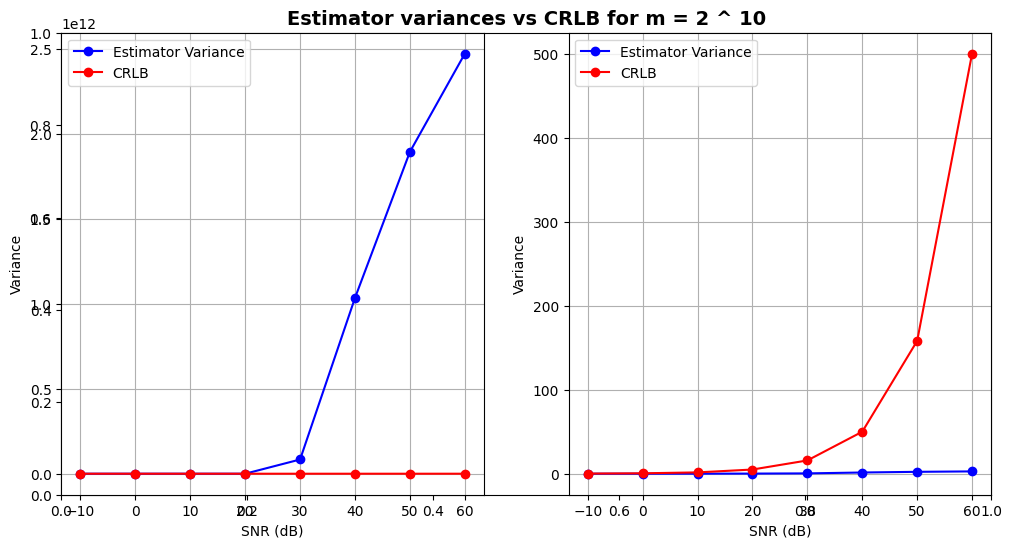

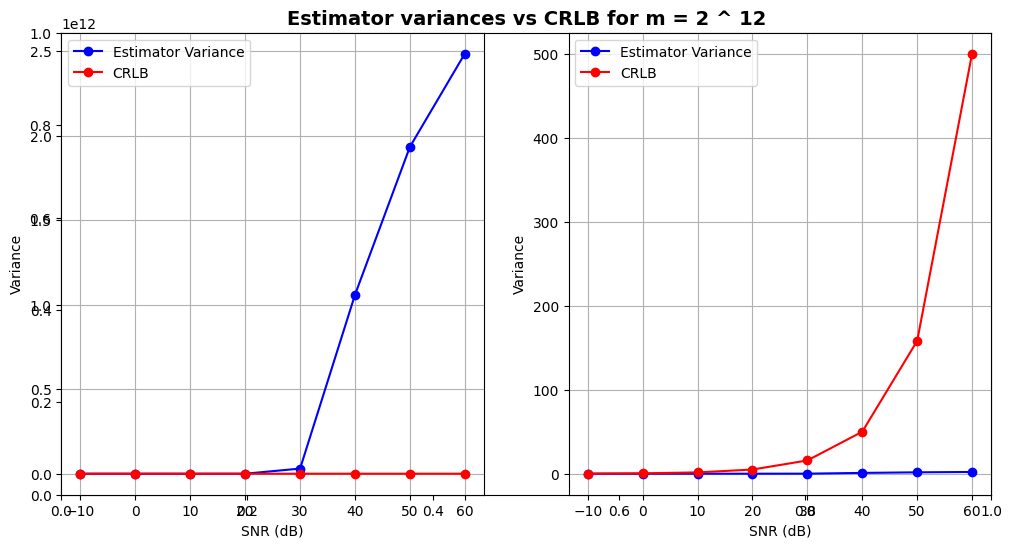

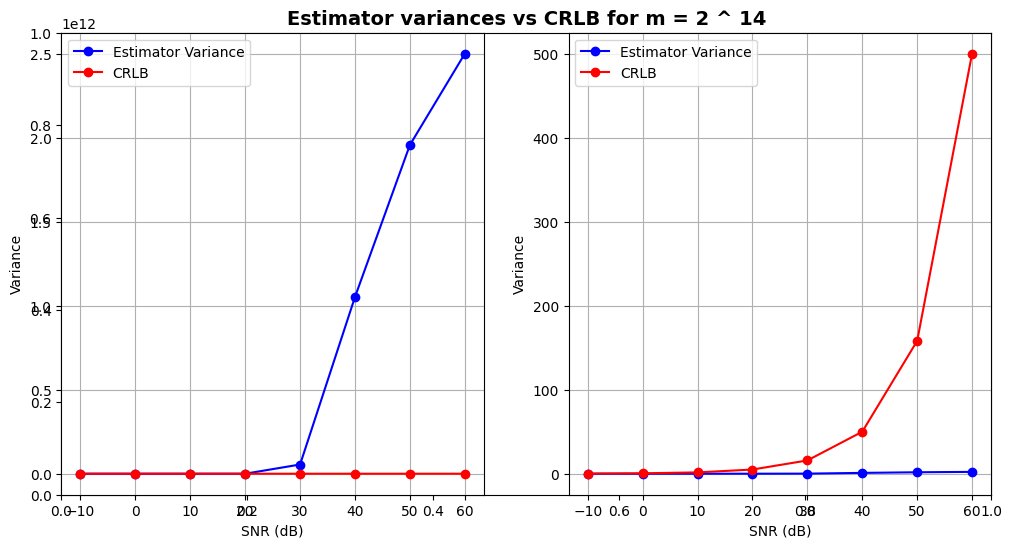

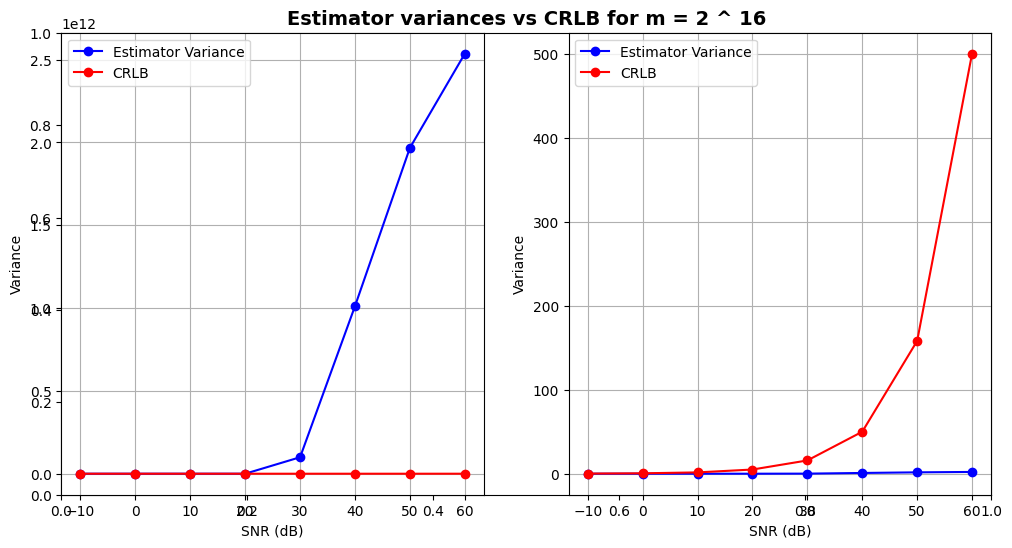

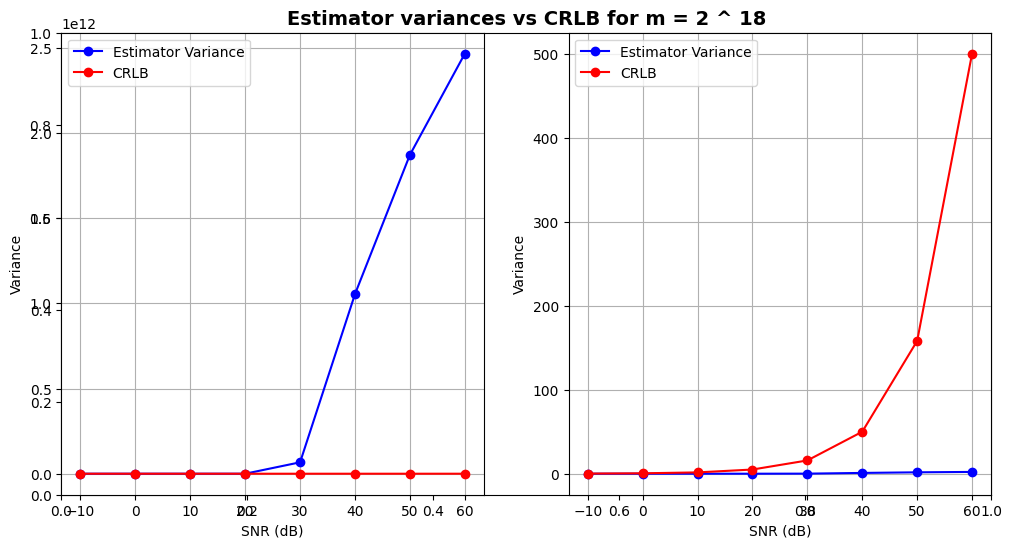

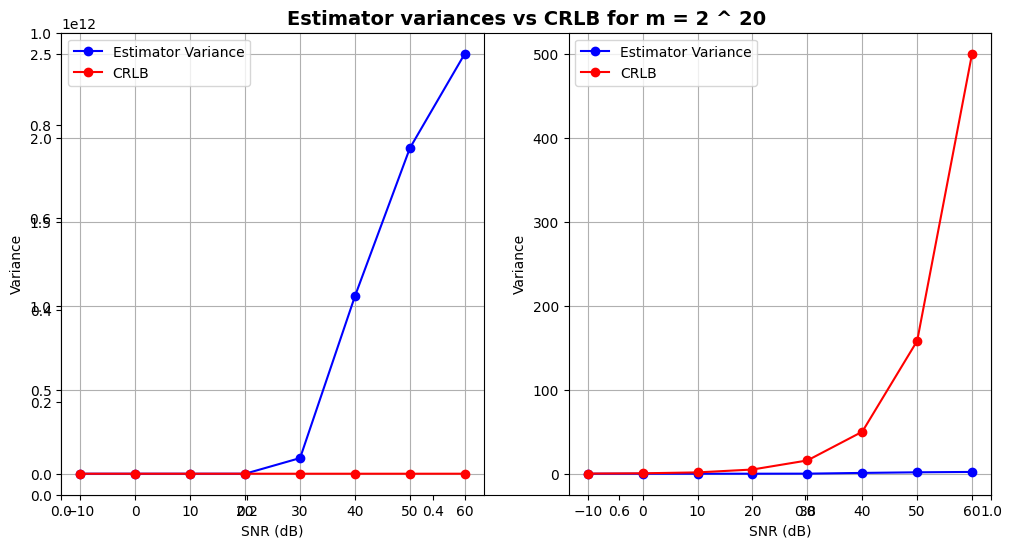

In [22]:
w_CRLB = W_CRLB(standard_deviation_list)
phi_CRLB = Phi_CRLB(standard_deviation_list)

num_estimations = 1000

for m in m_values:

    w_estimates, phi_estimates = [], []
    w0_variance_list = []
    phi_variance_list = []

    for sd in standard_deviation_list:

        for _ in range(num_estimations):

            w_estimate, phi_estimate = Sim_estimation(m, sd)

            w_estimates.append(w_estimate)
            phi_estimates.append(phi_estimate)
        
        w_mean = mean(w_estimates)
        w_error = w_mean - w_0
        print(f"Bias in frequency estimate for m = 2 ^ {int(np.log2(m))} and standard deviation = {sd}: {w_error}")

        phi_mean = mean(phi_estimates)
        phi_error = phi_mean - phi
        print(f"Bias in phase estimate for m = 2 ^ {int(np.log2(m))} and standard deviation = {sd}: {phi_error}")

        w_variance = variance(w_estimates, w_mean)
        print(f"Variance in frequency estimate for m = 2 ^ {int(np.log2(m))} and standard deviation = {sd}: {w_variance}")
        phi_variance = variance(phi_estimates, phi_mean)
        print(f"Variance in phase estimate for m = 2 ^ {int(np.log2(m))} and standard deviation = {sd}: {phi_variance}")

        w0_variance_list.append(w_variance)
        phi_variance_list.append(phi_variance)

    plt.figure(figsize=(12, 6))
    plt.title(f"Estimator variances vs CRLB for m = 2 ^ {int(np.log2(m))}", fontsize=14, fontweight='bold')
    
    # Frequency
    plt.subplot(1, 2, 1)
    plt.plot(SNR_db_list, w0_variance_list, marker='o', label = "Estimator Variance", color = "blue")
    plt.plot(SNR_db_list, w_CRLB, marker='o', label = "CRLB", color = "red")
    plt.xlabel('SNR (dB)')
    plt.ylabel('Variance')
    plt.grid(True)
    plt.legend()

    # Phase
    plt.subplot(1, 2, 2)
    plt.plot(SNR_db_list, phi_variance_list, marker='o', label = "Estimator Variance", color = "blue")
    plt.plot(SNR_db_list, phi_CRLB, marker='o', label = "CRLB", color = "red")
    plt.xlabel('SNR (dB)')
    plt.ylabel('Variance')
    plt.grid(True)
    plt.legend()
